# 🏨 Hotel Reservation Status Prediction — LightGBM Pipeline

**Target:** `Reservation_Status`
- **1** = No Cancellation (Checked In / Stay)
- **2** = Cancellation
- **3** = No Show

---
### Pipeline Overview
1. Install & Import Libraries
2. Load Data
3. Correlation Analysis — Target vs Features
4. Feature Selection (18 specified features)
5. Feature Importance + Spearman Correlation
6. Baseline LightGBM (Full Train — No Split)
7. Hyperparameter Tuning (Optuna)
8. Validation Dataset — Test Split & Prediction
9. Financial & Revenue Improvement Suggestions

## Step 1 — Install & Import Libraries

In [ ]:
# Install required packages (run once in Colab)
!pip install lightgbm optuna scikit-learn pandas numpy matplotlib seaborn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.8 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy import stats
from scipy.stats import spearmanr

import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50']

print('✅ All libraries imported successfully!')
print(f'   LightGBM version: {lgb.__version__}')

✅ All libraries imported successfully!
   LightGBM version: 4.6.0


## Step 2 — Load Data

> **Colab users:** Upload `train_encoded__1_.csv` and `valid_encoded__1_.csv` via the Files panel (left sidebar → 📁 icon → Upload).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ─── ADJUST PATHS IF NEEDED ───────────────────────────────────────────────────
TRAIN_PATH = '/content/drive/MyDrive/DSPL/train_encoded (1).csv'
VALID_PATH = '/content/drive/MyDrive/DSPL/valid_encoded (1).csv'
# ─────────────────────────────────────────────────────────────────────────────

train_df = pd.read_csv(TRAIN_PATH)
valid_df = pd.read_csv(VALID_PATH)

TARGET = 'Reservation_Status'
# Map to human-readable labels
LABEL_MAP = {1: 'No Cancellation', 2: 'Cancellation', 3: 'No Show'}

print(f'Train shape : {train_df.shape}')
print(f'Valid shape : {valid_df.shape}')
print()
print('Target distribution (Train):')
vc = train_df[TARGET].value_counts().rename(LABEL_MAP)
print(vc.to_string())
print(f'\nClass balance (%):')
print((vc / vc.sum() * 100).round(2).to_string())

Train shape : (27491, 38)
Valid shape : (2749, 38)

Target distribution (Train):
Reservation_Status
No Cancellation    21235
Cancellation        4134
No Show             2122

Class balance (%):
Reservation_Status
No Cancellation    77.24
Cancellation       15.04
No Show             7.72


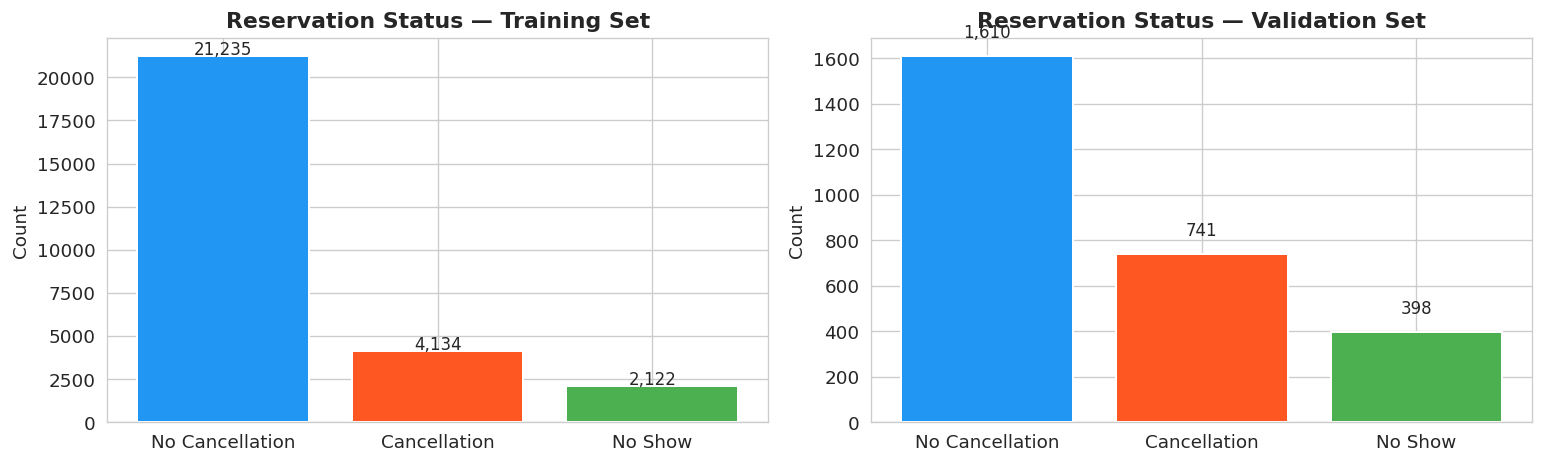

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, df, title in zip(axes, [train_df, valid_df], ['Training Set', 'Validation Set']):
    counts = df[TARGET].value_counts().rename(LABEL_MAP)
    bars = ax.bar(counts.index, counts.values, color=PALETTE, edgecolor='white', linewidth=1.2)
    ax.set_title(f'Reservation Status — {title}', fontweight='bold')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                f'{int(bar.get_height()):,}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight')
plt.show()

## Step 3 — Correlation Analysis

### 3a. Pearson Correlation of ALL features with `Reservation_Status`

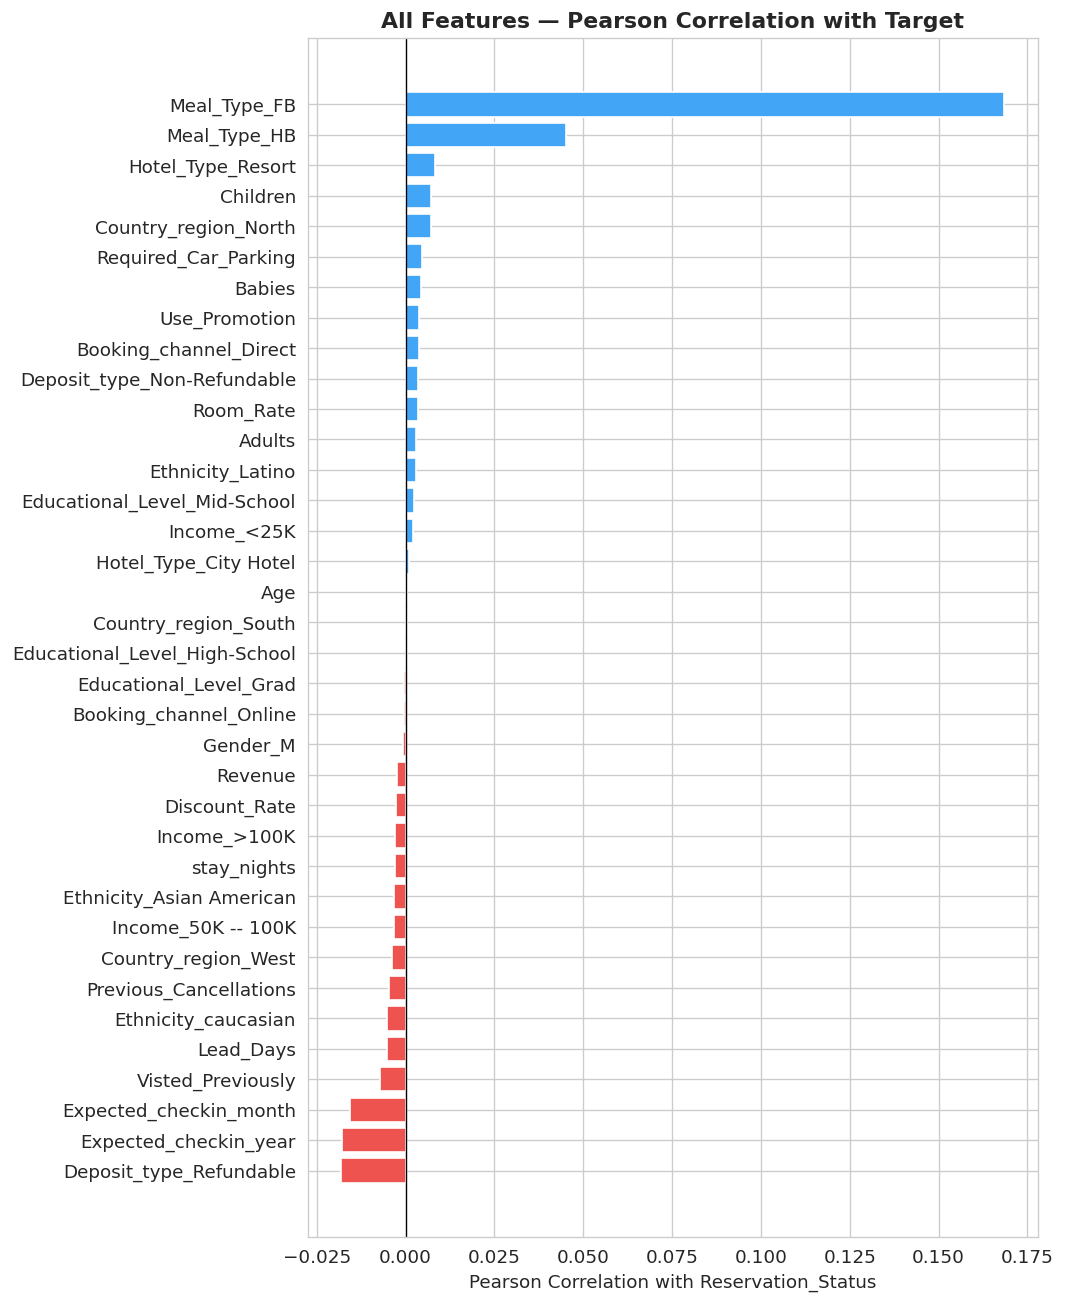


Top 10 POSITIVE correlations with target:
Deposit_type_Non-Refundable    0.0035
Booking_channel_Direct         0.0037
Use_Promotion                  0.0037
Babies                         0.0045
Required_Car_Parking           0.0045
Country_region_North           0.0071
Children                       0.0072
Hotel_Type_Resort              0.0084
Meal_Type_HB                   0.0450
Meal_Type_FB                   0.1685

Top 10 NEGATIVE correlations with target:
Deposit_type_Refundable    -0.0182
Expected_checkin_year      -0.0179
Expected_checkin_month     -0.0156
Visted_Previously          -0.0071
Lead_Days                  -0.0053
Ethnicity_caucasian        -0.0052
Previous_Cancellations     -0.0047
Country_region_West        -0.0039
Income_50K -- 100K         -0.0032
Ethnicity_Asian American   -0.0032


In [ ]:
feature_cols = [c for c in train_df.columns if c not in [TARGET, 'Reservation_id']]

pearson_corr = train_df[feature_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(9, 11))
colors = ['#EF5350' if v < 0 else '#42A5F5' for v in pearson_corr.values]
ax.barh(pearson_corr.index, pearson_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Reservation_Status')
ax.set_title('All Features — Pearson Correlation with Target', fontweight='bold')
plt.tight_layout()
plt.savefig('pearson_correlation_all.png', bbox_inches='tight')
plt.show()

print('\nTop 10 POSITIVE correlations with target:')
print(pearson_corr.tail(10).round(4).to_string())
print('\nTop 10 NEGATIVE correlations with target:')
print(pearson_corr.head(10).round(4).to_string())

### 3b. Full Correlation Heatmap — Feature Inter-Correlations

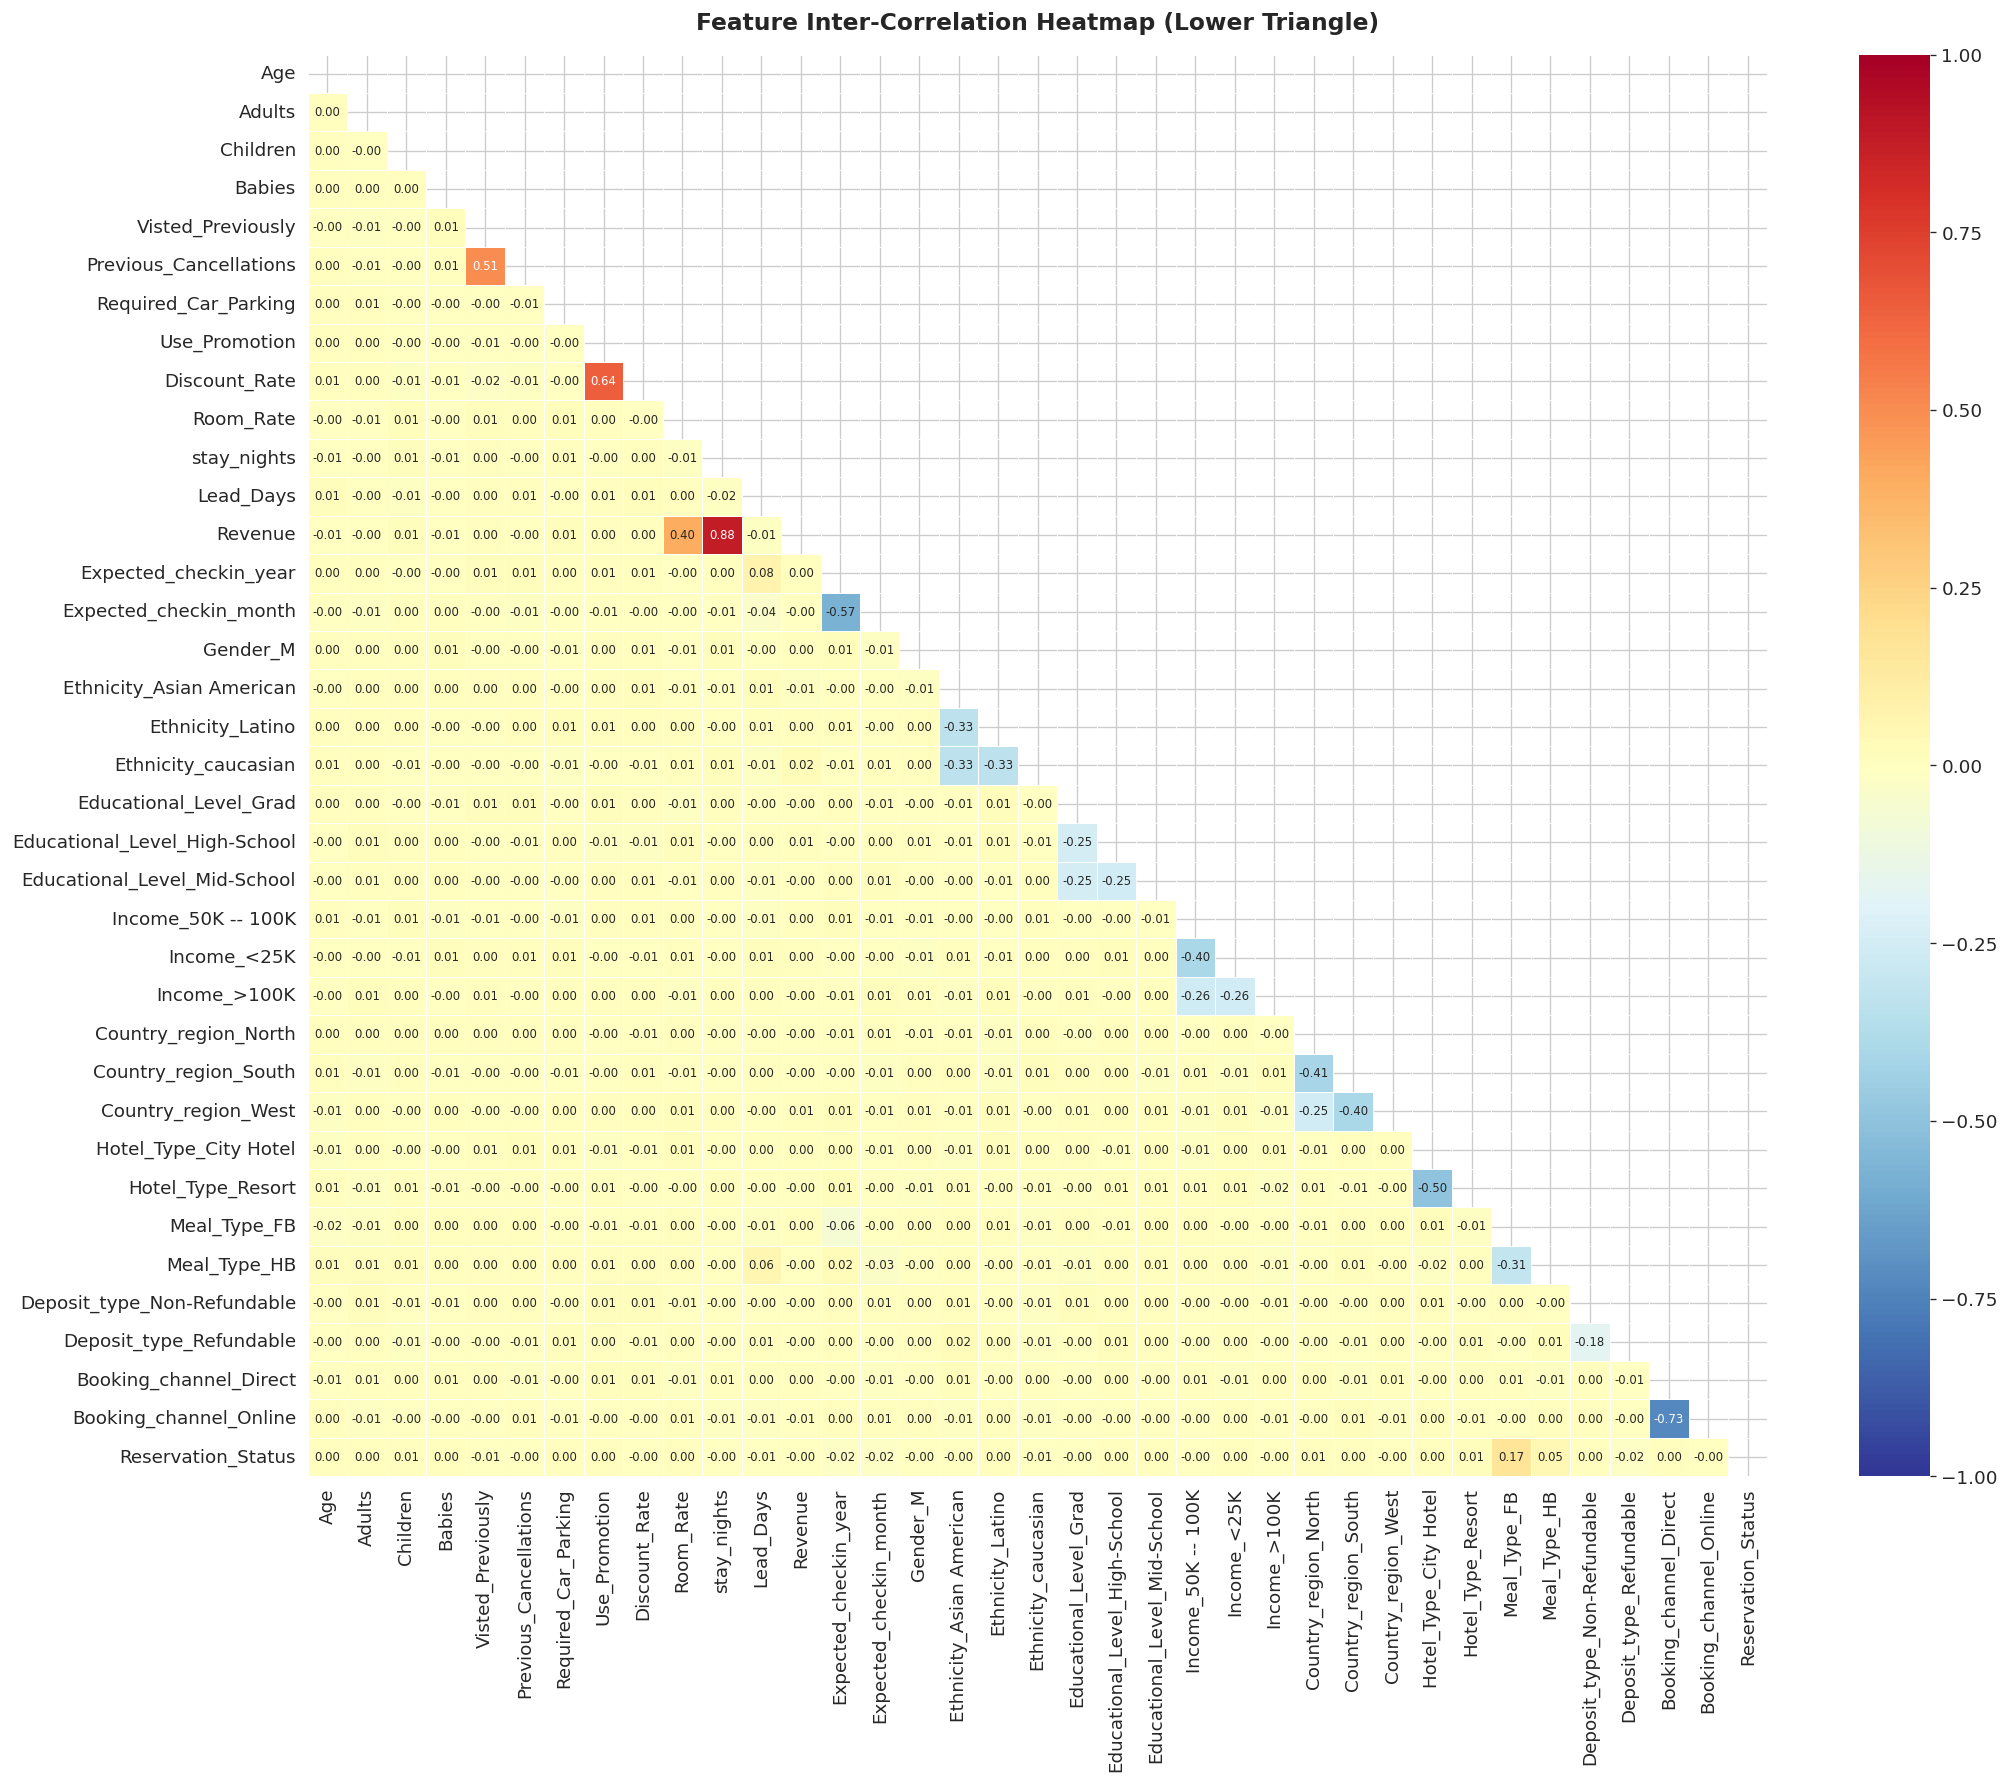

In [ ]:
# Compute full correlation matrix
corr_matrix = train_df[feature_cols + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={'size': 7}
)
ax.set_title('Feature Inter-Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Step 4 — Feature Selection (18 Specified Features)

In [ ]:
SELECTED_FEATURES = [
    'Meal_Type_FB',
    'Lead_Days',
    'Expected_checkin_month',
    'Expected_checkin_year',
    'Deposit_type_Refundable',
    'Meal_Type_HB',
    'Booking_channel_Online',
    'Hotel_Type_City Hotel',
    'Country_region_North',
    'Previous_Cancellations',
    'Use_Promotion',
    'Visted_Previously',
    'Discount_Rate',
    'Adults',
    'Babies',
    'Children',
]

# Remove duplicates (Use_Promotion was listed twice)
SELECTED_FEATURES = list(dict.fromkeys(SELECTED_FEATURES))

print(f'Selected {len(SELECTED_FEATURES)} features:')
for i, f in enumerate(SELECTED_FEATURES, 1):
    print(f'  {i:2d}. {f}')

# Verify all exist
missing = [f for f in SELECTED_FEATURES if f not in train_df.columns]
if missing:
    print(f'\n⚠️  Missing in dataset: {missing}')
else:
    print('\n✅ All selected features found in dataset.')

Selected 16 features:
   1. Meal_Type_FB
   2. Lead_Days
   3. Expected_checkin_month
   4. Expected_checkin_year
   5. Deposit_type_Refundable
   6. Meal_Type_HB
   7. Booking_channel_Online
   8. Hotel_Type_City Hotel
   9. Country_region_North
  10. Previous_Cancellations
  11. Use_Promotion
  12. Visted_Previously
  13. Discount_Rate
  14. Adults
  15. Babies
  16. Children

✅ All selected features found in dataset.


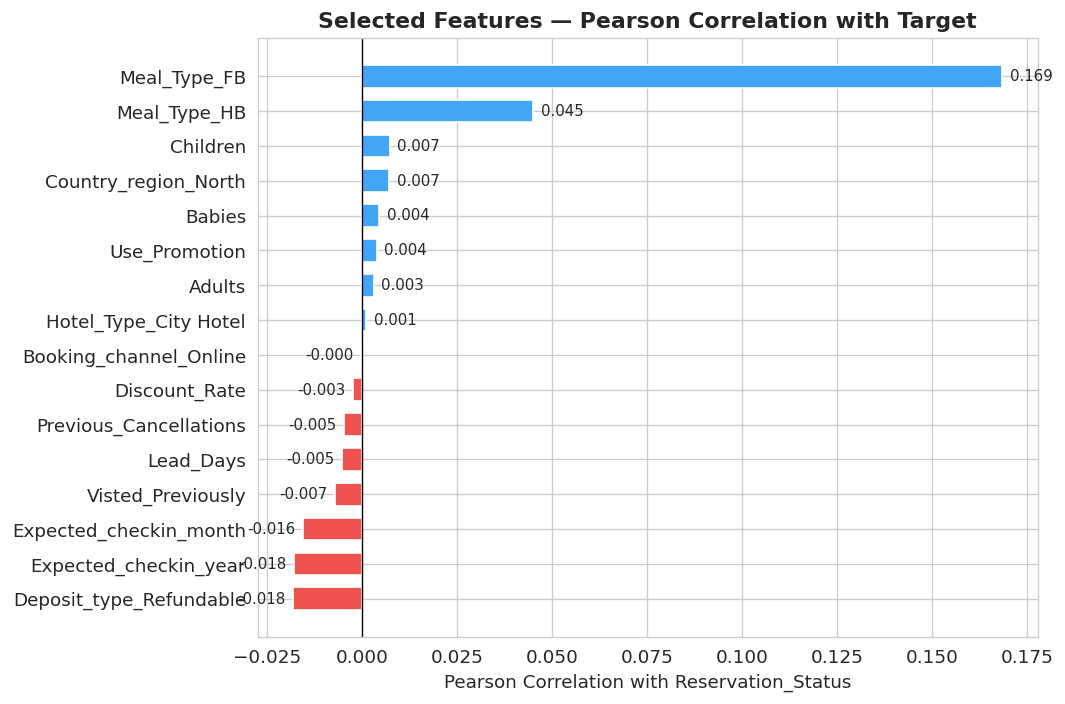

In [ ]:
# Correlation of SELECTED features with target
sel_pearson = train_df[SELECTED_FEATURES + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#EF5350' if v < 0 else '#42A5F5' for v in sel_pearson.values]
bars = ax.barh(sel_pearson.index, sel_pearson.values, color=colors, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, sel_pearson.values):
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Pearson Correlation with Reservation_Status')
ax.set_title('Selected Features — Pearson Correlation with Target', fontweight='bold')
plt.tight_layout()
plt.savefig('selected_features_correlation.png', bbox_inches='tight')
plt.show()

## Step 5 — Feature Importance + Spearman Correlation

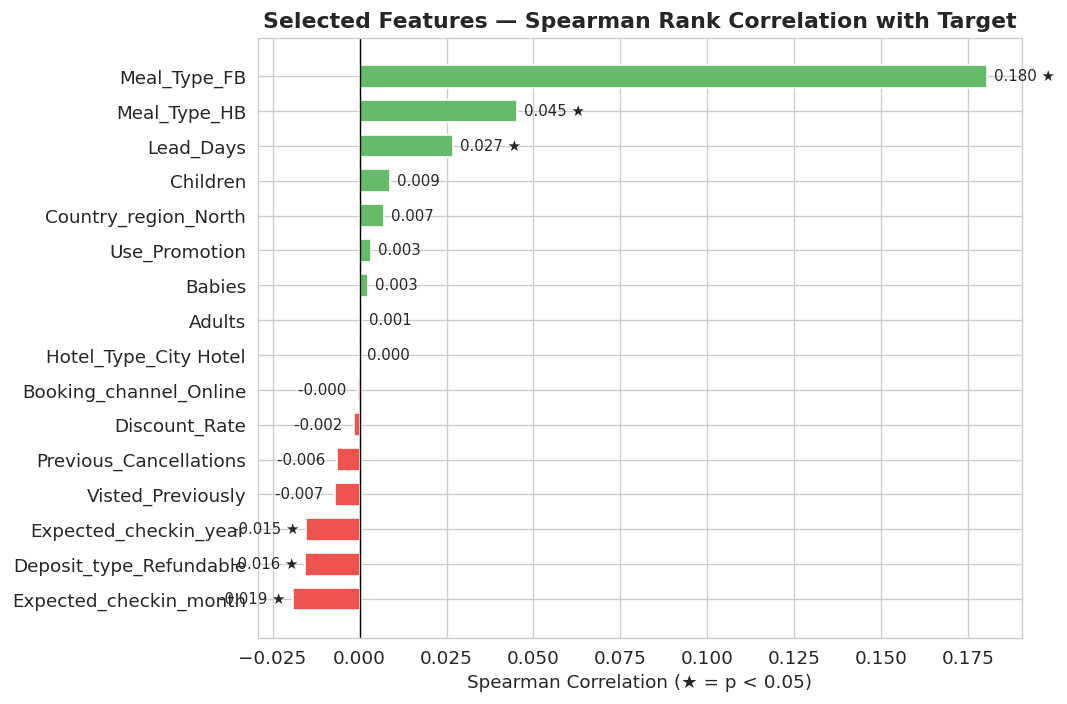


Spearman Correlation Summary:
                         spearman_r  p_value  significant
Expected_checkin_month      -0.0193   0.0014         True
Deposit_type_Refundable     -0.0157   0.0093         True
Expected_checkin_year       -0.0153   0.0110         True
Visted_Previously           -0.0071   0.2378        False
Previous_Cancellations      -0.0064   0.2854        False
Discount_Rate               -0.0016   0.7946        False
Booking_channel_Online      -0.0004   0.9439        False
Hotel_Type_City Hotel        0.0001   0.9805        False
Adults                       0.0008   0.8950        False
Babies                       0.0025   0.6726        False
Use_Promotion                0.0034   0.5718        False
Country_region_North         0.0070   0.2479        False
Children                     0.0086   0.1520        False
Lead_Days                    0.0270   0.0000         True
Meal_Type_HB                 0.0451   0.0000         True
Meal_Type_FB                 0.1804   0.0

In [ ]:
# Spearman correlation of selected features with target
spearman_results = {}
for feat in SELECTED_FEATURES:
    corr, pval = spearmanr(train_df[feat], train_df[TARGET])
    spearman_results[feat] = {'spearman_r': corr, 'p_value': pval}

spearman_df = pd.DataFrame(spearman_results).T.sort_values('spearman_r')
spearman_df['significant'] = spearman_df['p_value'] < 0.05

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#EF5350' if v < 0 else '#66BB6A' for v in spearman_df['spearman_r']]
bars = ax.barh(spearman_df.index, spearman_df['spearman_r'], color=colors, edgecolor='white', height=0.65)
ax.axvline(0, color='black', linewidth=0.8)
for bar, (_, row) in zip(bars, spearman_df.iterrows()):
    val = row['spearman_r']
    sig = '★' if row['significant'] else ''
    ax.text(val + (0.002 if val >= 0 else -0.002), bar.get_y() + bar.get_height()/2,
            f'{val:.3f} {sig}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_xlabel('Spearman Correlation (★ = p < 0.05)')
ax.set_title('Selected Features — Spearman Rank Correlation with Target', fontweight='bold')
plt.tight_layout()
plt.savefig('spearman_correlation.png', bbox_inches='tight')
plt.show()

print('\nSpearman Correlation Summary:')
print(spearman_df.round(4).to_string())

## Step 6 — Baseline LightGBM (Trained on Full Train Set — No Split)

> The entire training dataset is used. No train/test split is applied here.

In [ ]:
# Prepare full training data
X_train_full = train_df[SELECTED_FEATURES]
y_train_full = train_df[TARGET] - 1  # Convert to 0-indexed: 0=No Cancel, 1=Cancel, 2=No Show

print(f'Training data shape : {X_train_full.shape}')
print(f'Target distribution :\n{pd.Series(y_train_full).value_counts().rename({0:"No Cancellation", 1:"Cancellation", 2:"No Show"}).to_string()}')

Training data shape : (27491, 16)
Target distribution :
Reservation_Status
No Cancellation    21235
Cancellation        4134
No Show             2122


In [ ]:
def evaluate_model(model, X, y_true, dataset_name='Dataset', label_map=None):
    """Compute and display all 4 evaluation matrices."""
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    # AUC-ROC (OvR)
    classes = sorted(y_true.unique())
    y_bin = label_binarize(y_true, classes=classes)
    try:
        auc = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='weighted')
    except Exception:
        auc = float('nan')

    print(f'\n{'='*55}')
    print(f'  📊 Evaluation Matrix — {dataset_name}')
    print(f'{'='*55}')
    print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision  : {prec:.4f}  (weighted avg)')
    print(f'  Recall     : {rec:.4f}  (weighted avg)')
    print(f'  F1-Score   : {f1:.4f}  (weighted avg)')
    print(f'  AUC-ROC    : {auc:.4f}  (weighted OvR)')
    print(f'{'='*55}')

    target_names = [label_map[i+1] for i in classes] if label_map else [str(i) for i in classes]
    print(f'\n  Per-Class Report:')
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Confusion Matrix — {dataset_name}', fontweight='bold')
    plt.tight_layout()
    fname = f'confusion_matrix_{dataset_name.replace(" ","_").lower()}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}

print('✅ evaluate_model() function defined.')

✅ evaluate_model() function defined.


Training Baseline LightGBM on FULL training dataset...
✅ Baseline model trained!

  📊 Evaluation Matrix — Baseline — Full Train Set
  Accuracy   : 0.6931  (69.31%)
  Precision  : 0.8281  (weighted avg)
  Recall     : 0.6931  (weighted avg)
  F1-Score   : 0.7233  (weighted avg)
  AUC-ROC    : 0.8660  (weighted OvR)

  Per-Class Report:
                 precision    recall  f1-score   support

No Cancellation       0.95      0.66      0.78     21235
   Cancellation       0.42      0.78      0.55      4134
        No Show       0.35      0.87      0.50      2122

       accuracy                           0.69     27491
      macro avg       0.58      0.77      0.61     27491
   weighted avg       0.83      0.69      0.72     27491



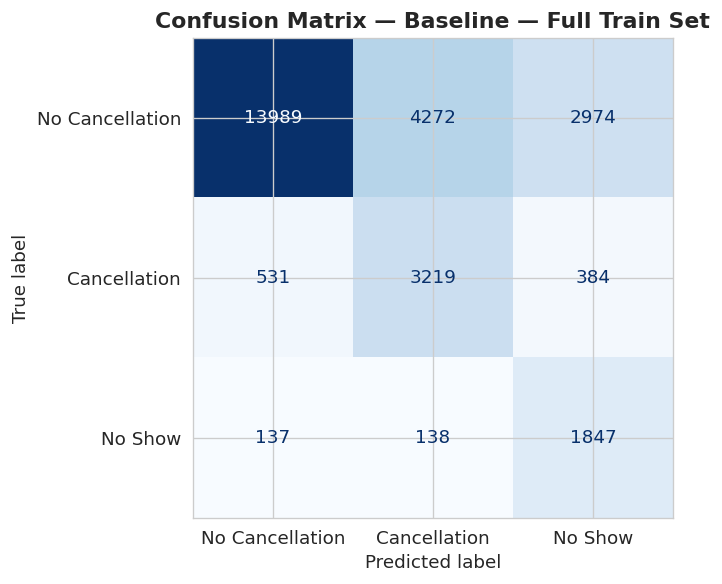

In [ ]:
# Baseline LightGBM
baseline_params = {
    'objective'       : 'multiclass',
    'num_class'       : 3,
    'metric'          : ['multi_logloss', 'multi_error'],
    'n_estimators'    : 500,
    'learning_rate'   : 0.05,
    'max_depth'       : 6,
    'num_leaves'      : 63,
    'min_child_samples': 20,
    'subsample'       : 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha'       : 0.1,
    'reg_lambda'      : 0.1,
    'class_weight'    : 'balanced',
    'n_jobs'          : -1,
    'random_state'    : 42,
    'verbose'         : -1
}

print('Training Baseline LightGBM on FULL training dataset...')
baseline_model = LGBMClassifier(**baseline_params)
baseline_model.fit(X_train_full, y_train_full)
print('✅ Baseline model trained!')

# Evaluate on training set
baseline_metrics = evaluate_model(
    baseline_model, X_train_full, y_train_full,
    dataset_name='Baseline — Full Train Set',
    label_map=LABEL_MAP
)

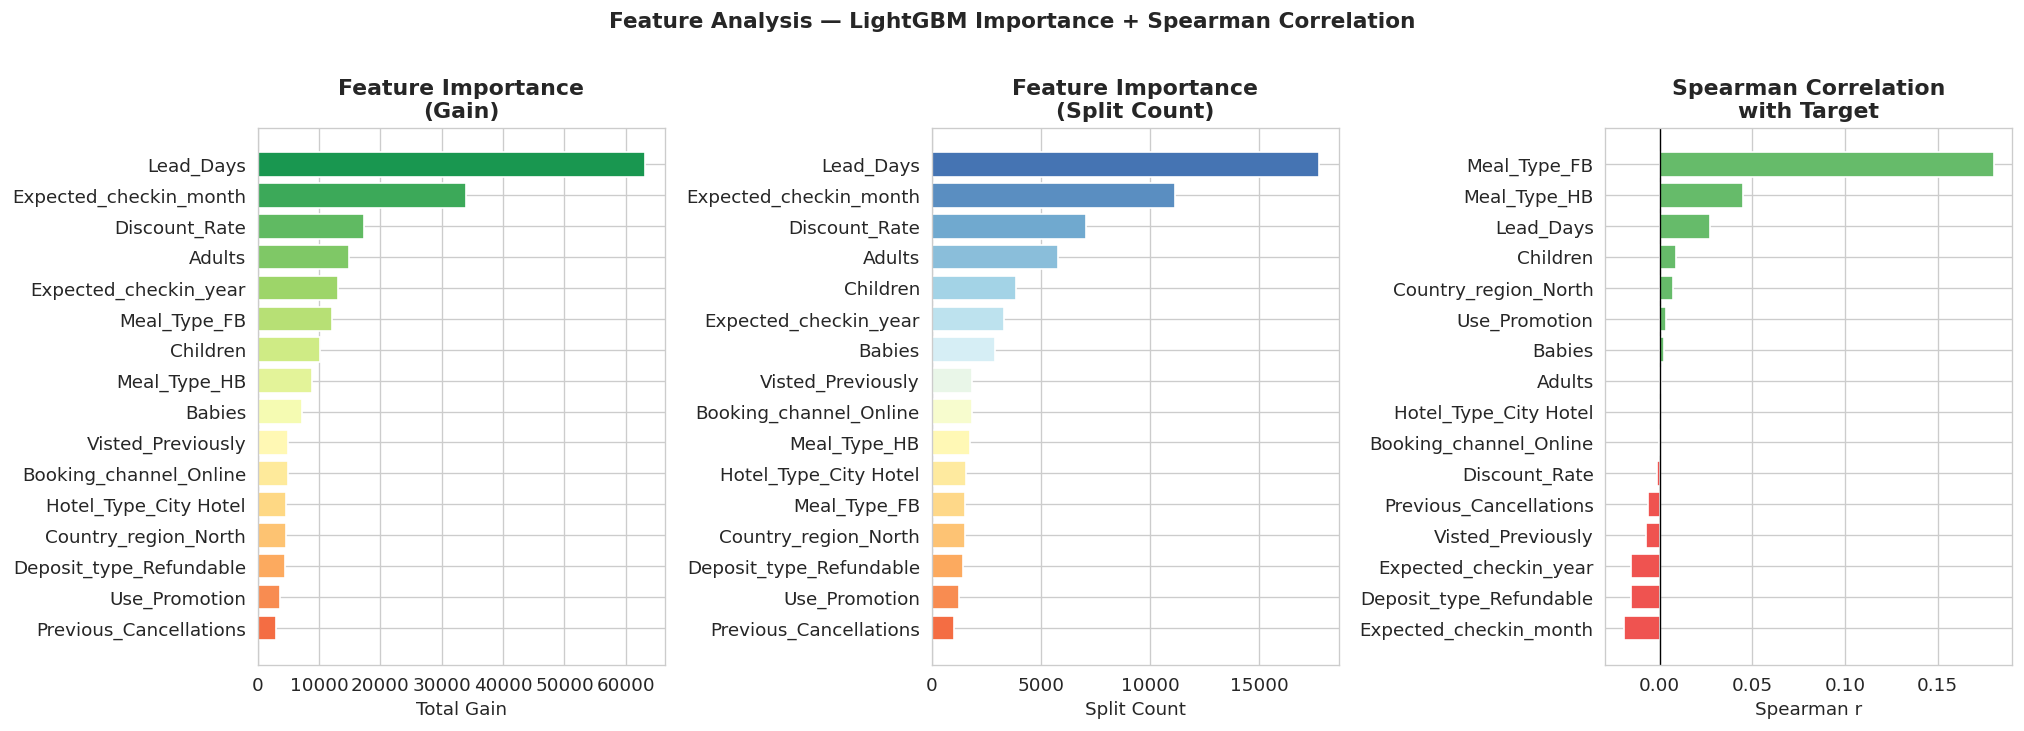


Feature Analysis Summary:
                feature  importance_gain  importance_split  spearman_r
              Lead_Days     63193.808767             17739    0.026988
 Expected_checkin_month     33906.625067             11131   -0.019270
          Discount_Rate     17374.269461              7049   -0.001570
                 Adults     14847.502765              5803    0.000796
  Expected_checkin_year     13138.050323              3314   -0.015343
           Meal_Type_FB     12108.201663              1548    0.180407
               Children     10182.493623              3871    0.008640
           Meal_Type_HB      8914.310866              1779    0.045136
                 Babies      7228.452599              2896    0.002549
      Visted_Previously      4977.435695              1851   -0.007120
 Booking_channel_Online      4869.042287              1838   -0.000424
  Hotel_Type_City Hotel      4574.433502              1577    0.000147
   Country_region_North      4541.394298          

In [ ]:
# Feature Importance from Baseline Model
imp_df = pd.DataFrame({
    'feature'   : SELECTED_FEATURES,
    'importance_gain'  : baseline_model.booster_.feature_importance(importance_type='gain'),
    'importance_split' : baseline_model.booster_.feature_importance(importance_type='split'),
}).sort_values('importance_gain', ascending=True)

# Merge with spearman
imp_df = imp_df.merge(spearman_df[['spearman_r']].reset_index().rename(columns={'index':'feature'}),
                       on='feature', how='left')

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# Gain importance
gain_sorted = imp_df.sort_values('importance_gain')
colors_gain = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(gain_sorted)))
axes[0].barh(gain_sorted['feature'], gain_sorted['importance_gain'], color=colors_gain, edgecolor='white')
axes[0].set_title('Feature Importance\n(Gain)', fontweight='bold')
axes[0].set_xlabel('Total Gain')

# Split importance
split_sorted = imp_df.sort_values('importance_split')
colors_split = plt.cm.RdYlBu(np.linspace(0.2, 0.9, len(split_sorted)))
axes[1].barh(split_sorted['feature'], split_sorted['importance_split'], color=colors_split, edgecolor='white')
axes[1].set_title('Feature Importance\n(Split Count)', fontweight='bold')
axes[1].set_xlabel('Split Count')

# Spearman correlation
spear_sorted = imp_df.sort_values('spearman_r')
colors_sp = ['#EF5350' if v < 0 else '#66BB6A' for v in spear_sorted['spearman_r']]
axes[2].barh(spear_sorted['feature'], spear_sorted['spearman_r'], color=colors_sp, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title('Spearman Correlation\nwith Target', fontweight='bold')
axes[2].set_xlabel('Spearman r')

plt.suptitle('Feature Analysis — LightGBM Importance + Spearman Correlation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_spearman.png', bbox_inches='tight')
plt.show()

print('\nFeature Analysis Summary:')
print(imp_df[['feature','importance_gain','importance_split','spearman_r']].sort_values('importance_gain', ascending=False).to_string(index=False))

## Step 7 — Hyperparameter Tuning

We run **three tuning methods** on the full training set using Stratified K-Fold cross-validation:
1. **Optuna (Bayesian)** — Most powerful, optimises weighted F1
2. **Manual Grid Search** — Interpretable parameter sweep  
3. **Final tuned model** — Best params retrained on full train

In [ ]:
# ── Method 1: Optuna Bayesian Optimisation ──────────────────────────────────
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)

def objective(trial):
    params = {
        'objective'        : 'multiclass',
        'num_class'        : 3,
        'metric'           : 'multi_logloss',
        'n_estimators'     : trial.suggest_int('n_estimators', 200, 1000, step=100),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 5.0, log=True),
        'class_weight'     : 'balanced',
        'n_jobs'           : -1,
        'random_state'     : 42,
        'verbose'          : -1
    }
    model = LGBMClassifier(**params)
    scores = cross_val_score(model, X_train_full, y_train_full,
                             cv=skf, scoring='f1_weighted', n_jobs=-1)
    return scores.mean()

print('🔍 Running Optuna Bayesian Optimisation (50 trials)...')
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_optuna_params = study.best_params
best_optuna_params.update({'objective': 'multiclass', 'num_class': 3,
                            'metric': 'multi_logloss', 'class_weight': 'balanced',
                            'n_jobs': -1, 'random_state': 42, 'verbose': -1})

print(f'\n✅ Optuna best CV F1 (weighted): {study.best_value:.4f}')
print('Best params:')
for k, v in best_optuna_params.items():
    print(f'  {k}: {v}')

🔍 Running Optuna Bayesian Optimisation (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


✅ Optuna best CV F1 (weighted): 0.6740
Best params:
  n_estimators: 700
  learning_rate: 0.1742345779042042
  max_depth: 10
  num_leaves: 107
  min_child_samples: 14
  subsample: 0.6753535765721028
  colsample_bytree: 0.7202858728190467
  reg_alpha: 0.07857446323901016
  reg_lambda: 0.027797988254127128
  objective: multiclass
  num_class: 3
  metric: multi_logloss
  class_weight: balanced
  n_jobs: -1
  random_state: 42
  verbose: -1


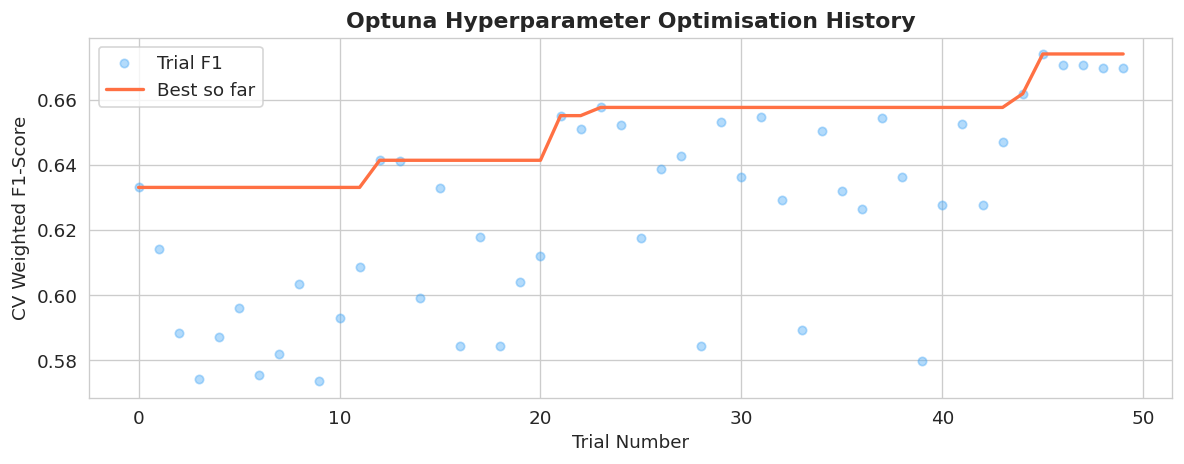

In [ ]:
# Plot Optuna optimisation history
trial_values = [t.value for t in study.trials if t.value is not None]
running_best = pd.Series(trial_values).cummax()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(trial_values)), trial_values, alpha=0.4, s=25, color='#42A5F5', label='Trial F1')
ax.plot(range(len(running_best)), running_best, color='#FF7043', linewidth=2, label='Best so far')
ax.set_xlabel('Trial Number')
ax.set_ylabel('CV Weighted F1-Score')
ax.set_title('Optuna Hyperparameter Optimisation History', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('optuna_history.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Method 2: Manual Parameter Grid Search ───────────────────────────────────
print('🔍 Running Manual Grid Search (focused grid)...')

param_grid = [
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'num_leaves': 31},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 7, 'num_leaves': 63},
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 'num_leaves': 50},
    {'n_estimators': 700, 'learning_rate': 0.02, 'max_depth': 8, 'num_leaves': 100},
    {'n_estimators': 400, 'learning_rate': 0.1,  'max_depth': 4, 'num_leaves': 40},
]

grid_results = []
for i, pg in enumerate(param_grid, 1):
    m = LGBMClassifier(
        objective='multiclass', num_class=3, metric='multi_logloss',
        class_weight='balanced', subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=0.1, n_jobs=-1, random_state=42, verbose=-1,
        **pg
    )
    scores = cross_val_score(m, X_train_full, y_train_full, cv=skf, scoring='f1_weighted', n_jobs=-1)
    grid_results.append({**pg, 'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()})
    print(f'  Grid {i}/5: F1={scores.mean():.4f} ± {scores.std():.4f} | params={pg}')

grid_df = pd.DataFrame(grid_results).sort_values('cv_f1_mean', ascending=False)
best_grid_params = grid_df.iloc[0].to_dict()
print(f'\n✅ Best Grid Search F1: {best_grid_params["cv_f1_mean"]:.4f}')
print(grid_df.round(4).to_string(index=False))

🔍 Running Manual Grid Search (focused grid)...
  Grid 1/5: F1=0.5812 ± 0.0073 | params={'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'num_leaves': 31}
  Grid 2/5: F1=0.6199 ± 0.0052 | params={'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 7, 'num_leaves': 63}
  Grid 3/5: F1=0.5943 ± 0.0063 | params={'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 6, 'num_leaves': 50}
  Grid 4/5: F1=0.6193 ± 0.0051 | params={'n_estimators': 700, 'learning_rate': 0.02, 'max_depth': 8, 'num_leaves': 100}
  Grid 5/5: F1=0.5830 ± 0.0063 | params={'n_estimators': 400, 'learning_rate': 0.1, 'max_depth': 4, 'num_leaves': 40}

✅ Best Grid Search F1: 0.6199
 n_estimators  learning_rate  max_depth  num_leaves  cv_f1_mean  cv_f1_std
          500           0.05          7          63      0.6199     0.0052
          700           0.02          8         100      0.6193     0.0051
          500           0.03          6          50      0.5943     0.0063
          400           0.1

Training Final Tuned LightGBM (Optuna best params) on FULL training set...
✅ Final tuned model trained!

  📊 Evaluation Matrix — Tuned Model — Full Train Set
  Accuracy   : 0.9946  (99.46%)
  Precision  : 0.9948  (weighted avg)
  Recall     : 0.9946  (weighted avg)
  F1-Score   : 0.9946  (weighted avg)
  AUC-ROC    : 1.0000  (weighted OvR)

  Per-Class Report:
                 precision    recall  f1-score   support

No Cancellation       1.00      0.99      1.00     21235
   Cancellation       0.97      1.00      0.98      4134
        No Show       0.99      1.00      1.00      2122

       accuracy                           0.99     27491
      macro avg       0.99      1.00      0.99     27491
   weighted avg       0.99      0.99      0.99     27491



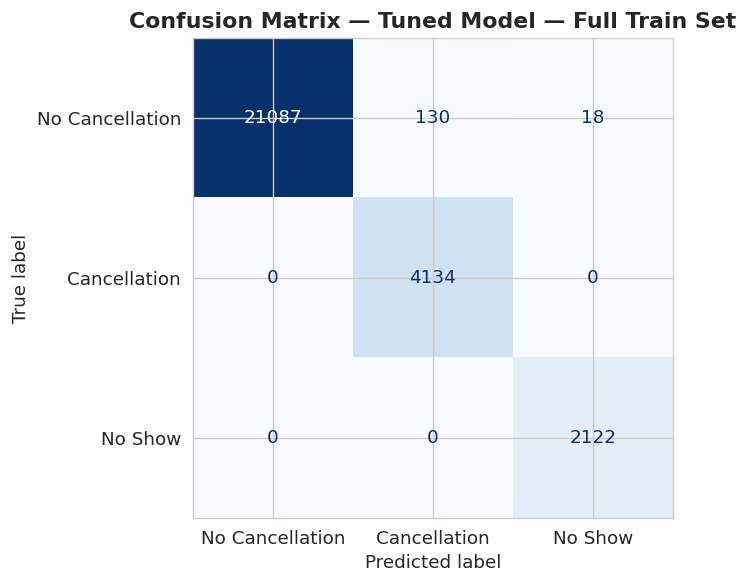

In [ ]:
# ── Train Final Tuned Model on Full Training Set ─────────────────────────────
print('Training Final Tuned LightGBM (Optuna best params) on FULL training set...')

final_model = LGBMClassifier(**best_optuna_params)
final_model.fit(X_train_full, y_train_full)
print('✅ Final tuned model trained!')

# Evaluate on train set
tuned_train_metrics = evaluate_model(
    final_model, X_train_full, y_train_full,
    dataset_name='Tuned Model — Full Train Set',
    label_map=LABEL_MAP
)

Computing cross-validated metrics (5-Fold Stratified)...
  CV accuracy    : 0.6994 ± 0.0041
  CV precision   : 0.6537 ± 0.0033
  CV recall      : 0.6994 ± 0.0041
  CV f1          : 0.6740 ± 0.0032


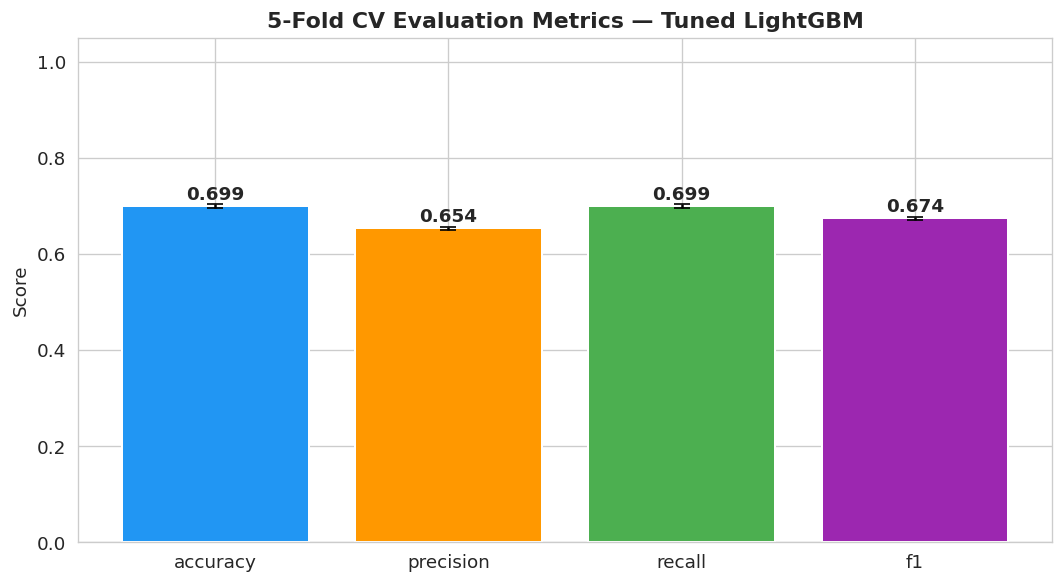

In [ ]:
# ── Cross-Validated Metrics on Full Train Set ─────────────────────────────────
print('Computing cross-validated metrics (5-Fold Stratified)...')

cv_metrics = {}
for metric_name, scoring in [('accuracy','accuracy'), ('precision','precision_weighted'),
                               ('recall','recall_weighted'), ('f1','f1_weighted')]:
    scores = cross_val_score(final_model, X_train_full, y_train_full,
                              cv=skf, scoring=scoring, n_jobs=-1)
    cv_metrics[metric_name] = {'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f'  CV {metric_name:12s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Bar chart of CV metrics
fig, ax = plt.subplots(figsize=(9, 5))
names = list(cv_metrics.keys())
means = [cv_metrics[k]['mean'] for k in names]
stds  = [cv_metrics[k]['std']  for k in names]
bar_colors = ['#2196F3','#FF9800','#4CAF50','#9C27B0']
bars = ax.bar(names, means, yerr=stds, color=bar_colors, capsize=5,
              edgecolor='white', linewidth=1.2)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('5-Fold CV Evaluation Metrics — Tuned LightGBM', fontweight='bold')
for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
            f'{mean:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('cv_metrics.png', bbox_inches='tight')
plt.show()

## Step 8 — Validation Dataset: Test Split & Prediction

The validation dataset is split:
- **50% → Test set** (evaluate model performance with ground truth)
- **50% → Prediction set** (simulate real-world prediction — no ground truth used)

In [ ]:
X_valid = valid_df[SELECTED_FEATURES]
y_valid = valid_df[TARGET] - 1  # 0-indexed

# 50/50 split
X_test, X_pred, y_test, y_pred_true = train_test_split(
    X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42
)

print(f'Validation dataset total   : {len(X_valid):,} rows')
print(f'  → Test set (50%)         : {len(X_test):,} rows  [with ground truth]')
print(f'  → Prediction set (50%)   : {len(X_pred):,} rows  [simulated unseen]')
print()
print('Test set class distribution:')
print(pd.Series(y_test.values).value_counts().rename({0:'No Cancel',1:'Cancel',2:'No Show'}).to_string())

Validation dataset total   : 2,749 rows
  → Test set (50%)         : 1,374 rows  [with ground truth]
  → Prediction set (50%)   : 1,375 rows  [simulated unseen]

Test set class distribution:
No Cancel    805
Cancel       370
No Show      199



  📊 Evaluation Matrix — Tuned Model — Validation Test Set
  Accuracy   : 0.5597  (55.97%)
  Precision  : 0.4453  (weighted avg)
  Recall     : 0.5597  (weighted avg)
  F1-Score   : 0.4538  (weighted avg)
  AUC-ROC    : 0.5046  (weighted OvR)

  Per-Class Report:
                 precision    recall  f1-score   support

No Cancellation       0.59      0.92      0.72       805
   Cancellation       0.32      0.06      0.11       370
        No Show       0.11      0.02      0.03       199

       accuracy                           0.56      1374
      macro avg       0.34      0.34      0.29      1374
   weighted avg       0.45      0.56      0.45      1374



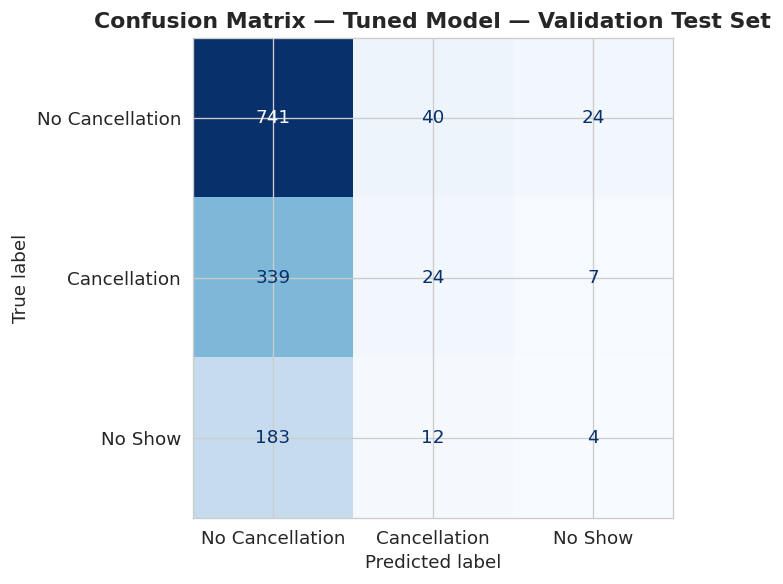

In [ ]:
# Evaluate on Test Set
test_metrics = evaluate_model(
    final_model, X_test, y_test,
    dataset_name='Tuned Model — Validation Test Set',
    label_map=LABEL_MAP
)

In [ ]:
# Predictions on Unseen Prediction Set
pred_labels = final_model.predict(X_pred)
pred_proba  = final_model.predict_proba(X_pred)

# Build results dataframe
pred_results = X_pred.copy().reset_index(drop=True)
pred_results['Predicted_Status_Code']  = pred_labels
pred_results['Predicted_Status_Label'] = pd.Series(pred_labels).map(
    {0: 'No Cancellation', 1: 'Cancellation', 2: 'No Show'})
pred_results['Prob_No_Cancel']    = pred_proba[:, 0].round(4)
pred_results['Prob_Cancellation'] = pred_proba[:, 1].round(4)
pred_results['Prob_No_Show']      = pred_proba[:, 2].round(4)
pred_results['Confidence']        = pred_proba.max(axis=1).round(4)
pred_results['High_Risk'] = pred_results.apply(
    lambda r: '⚠️ HIGH RISK' if (r['Prob_Cancellation'] + r['Prob_No_Show']) > 0.5 else 'Low Risk', axis=1)

# Also compare with actual for verification
pred_results['Actual_Status_Code']  = y_pred_true.values
pred_results['Actual_Status_Label'] = pd.Series(y_pred_true.values).map(
    {0: 'No Cancellation', 1: 'Cancellation', 2: 'No Show'})
pred_results['Correct'] = (pred_results['Predicted_Status_Code'] == pred_results['Actual_Status_Code'])

print(f'\n📋 Prediction Results Summary:')
print(pred_results['Predicted_Status_Label'].value_counts().to_string())
print(f'\nOverall Accuracy on Prediction Set: {pred_results["Correct"].mean():.4f} ({pred_results["Correct"].mean()*100:.2f}%)')
print(f'\nHigh Risk Reservations:')
print(pred_results['High_Risk'].value_counts().to_string())
print(f'\nSample Predictions (first 10 rows):')
display_cols = ['Predicted_Status_Label', 'Prob_No_Cancel', 'Prob_Cancellation',
                'Prob_No_Show', 'Confidence', 'High_Risk', 'Actual_Status_Label']
print(pred_results[display_cols].head(10).to_string(index=False))


📋 Prediction Results Summary:
Predicted_Status_Label
No Cancellation    1237
Cancellation        104
No Show              34

Overall Accuracy on Prediction Set: 0.5615 (56.15%)

High Risk Reservations:
High_Risk
Low Risk        1220
⚠️ HIGH RISK     155

Sample Predictions (first 10 rows):
Predicted_Status_Label  Prob_No_Cancel  Prob_Cancellation  Prob_No_Show  Confidence    High_Risk Actual_Status_Label
       No Cancellation          0.5378             0.4552        0.0071      0.5378     Low Risk     No Cancellation
       No Cancellation          0.9898             0.0036        0.0065      0.9898     Low Risk     No Cancellation
       No Cancellation          0.9992             0.0002        0.0006      0.9992     Low Risk             No Show
       No Cancellation          0.5630             0.4025        0.0345      0.5630     Low Risk     No Cancellation
          Cancellation          0.4305             0.5615        0.0080      0.5615 ⚠️ HIGH RISK             No Show
     

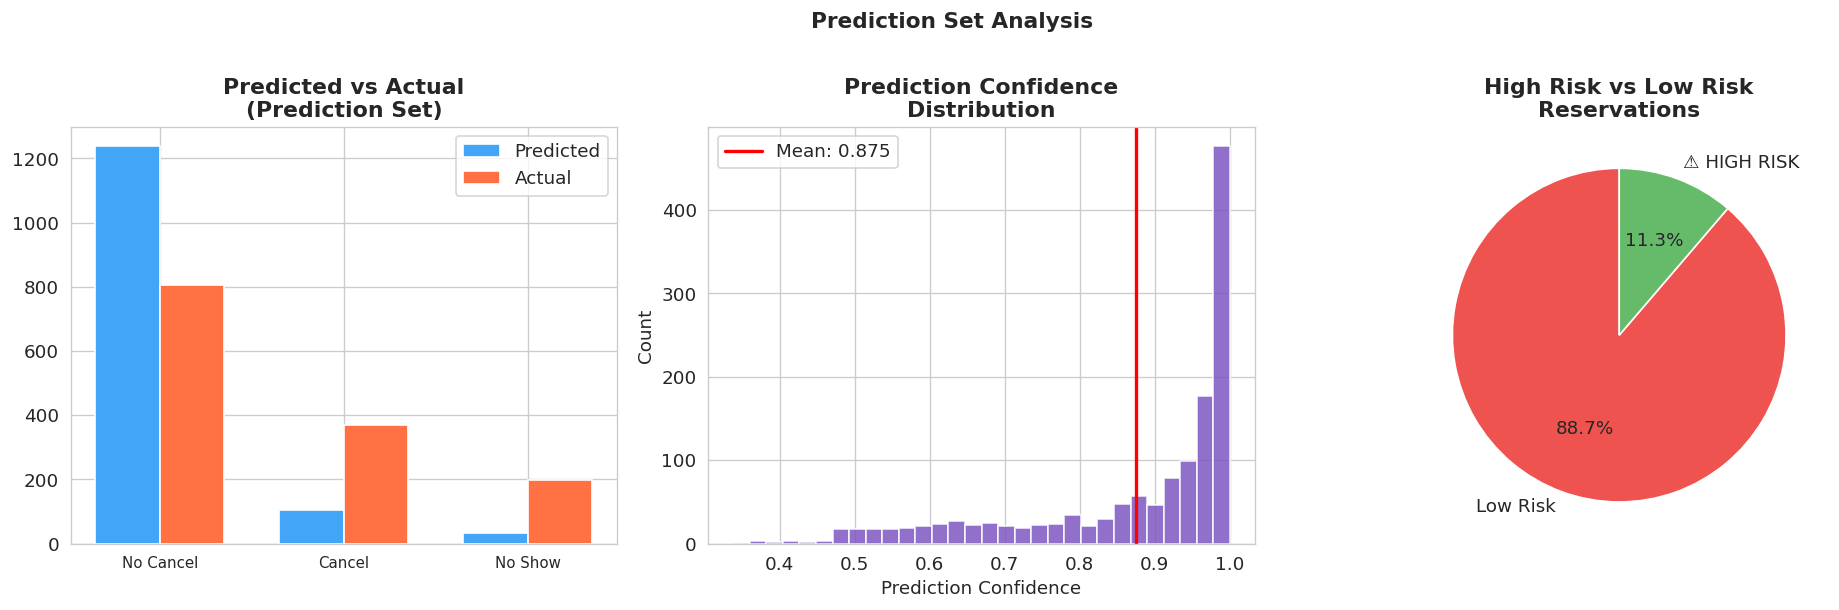

In [ ]:
# Visualise prediction distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
pred_counts = pred_results['Predicted_Status_Label'].value_counts()
act_counts  = pred_results['Actual_Status_Label'].value_counts()
x = np.arange(len(pred_counts))
w = 0.35
axes[0].bar(x - w/2, [pred_counts.get(l,0) for l in ['No Cancellation','Cancellation','No Show']],
            w, label='Predicted', color='#42A5F5', edgecolor='white')
axes[0].bar(x + w/2, [act_counts.get(l,0) for l in ['No Cancellation','Cancellation','No Show']],
            w, label='Actual', color='#FF7043', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['No Cancel','Cancel','No Show'], fontsize=9)
axes[0].set_title('Predicted vs Actual\n(Prediction Set)', fontweight='bold')
axes[0].legend()

# Confidence distribution
axes[1].hist(pred_results['Confidence'], bins=30, color='#7E57C2', edgecolor='white', alpha=0.85)
axes[1].axvline(pred_results['Confidence'].mean(), color='red', linewidth=2,
                label=f'Mean: {pred_results["Confidence"].mean():.3f}')
axes[1].set_xlabel('Prediction Confidence')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Confidence\nDistribution', fontweight='bold')
axes[1].legend()

# Risk breakdown
risk_counts = pred_results['High_Risk'].value_counts()
axes[2].pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
            colors=['#EF5350','#66BB6A'], startangle=90)
axes[2].set_title('High Risk vs Low Risk\nReservations', fontweight='bold')

plt.suptitle('Prediction Set Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prediction_analysis.png', bbox_inches='tight')
plt.show()


📊 FINAL METRICS COMPARISON
                  accuracy  precision  recall      f1
Baseline (Train)    0.6931     0.8281  0.6931  0.7233
Tuned (Train)       0.9946     0.9948  0.9946  0.9946
Tuned (Test)        0.5597     0.4453  0.5597  0.4538


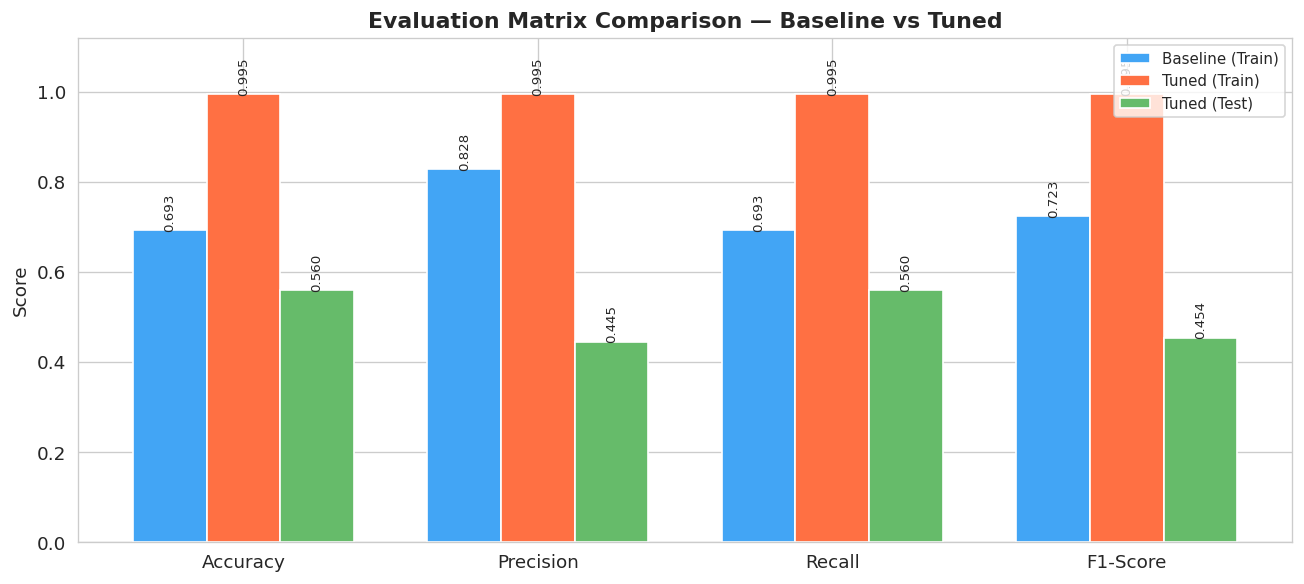

In [ ]:
# ── Final Metrics Comparison Table ──────────────────────────────────────────
comparison = pd.DataFrame({
    'Baseline (Train)' : baseline_metrics,
    'Tuned (Train)'    : tuned_train_metrics,
    'Tuned (Test)'     : test_metrics,
}).T.drop(columns=['auc'])

print('\n📊 FINAL METRICS COMPARISON')
print('='*60)
print(comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(4)
metrics = ['accuracy', 'precision', 'recall', 'f1']
datasets = list(comparison.index)
width = 0.25
colors_cmp = ['#42A5F5', '#FF7043', '#66BB6A']

for i, (ds, col) in enumerate(zip(datasets, colors_cmp)):
    vals = [comparison.loc[ds, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=ds, color=col, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{v:.3f}', ha='center', fontsize=8, rotation=90)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score'], fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Evaluation Matrix Comparison — Baseline vs Tuned', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('metrics_comparison.png', bbox_inches='tight')
plt.show()

In [ ]:
# Save predictions to CSV
pred_results.to_csv('hotel_reservation_predictions.csv', index=False)
print('✅ Predictions saved to hotel_reservation_predictions.csv')
print(f'   Shape: {pred_results.shape}')

✅ Predictions saved to hotel_reservation_predictions.csv
   Shape: (1375, 26)


## Step 9 — Financial & Revenue Improvement Suggestions

Using model predictions to generate actionable revenue strategies.

In [ ]:
# ── Financial Analysis ────────────────────────────────────────────────────────
# Merge predictions with original valid_df financial columns
valid_pred_full = valid_df.iloc[X_pred.index.tolist()].copy().reset_index(drop=True)
valid_pred_full['Predicted_Status'] = pred_results['Predicted_Status_Label'].values
valid_pred_full['Prob_Cancel']       = pred_results['Prob_Cancellation'].values
valid_pred_full['Prob_No_Show']      = pred_results['Prob_No_Show'].values
valid_pred_full['Risk_Score']        = (valid_pred_full['Prob_Cancel'] + valid_pred_full['Prob_No_Show']).round(4)
valid_pred_full['High_Risk']         = valid_pred_full['Risk_Score'] > 0.5

print('\n💰 Revenue & Financial Analysis')
print('='*60)

# Revenue at risk
if 'Revenue' in valid_pred_full.columns:
    total_revenue   = valid_pred_full['Revenue'].sum()
    cancel_revenue  = valid_pred_full.loc[valid_pred_full['Predicted_Status']=='Cancellation', 'Revenue'].sum()
    noshow_revenue  = valid_pred_full.loc[valid_pred_full['Predicted_Status']=='No Show',       'Revenue'].sum()
    at_risk         = cancel_revenue + noshow_revenue

    print(f'  Total Expected Revenue          : ${total_revenue:>12,.2f}')
    print(f'  Revenue at Risk (Cancellations) : ${cancel_revenue:>12,.2f}  ({cancel_revenue/total_revenue*100:.1f}%)')
    print(f'  Revenue at Risk (No Shows)      : ${noshow_revenue:>12,.2f}  ({noshow_revenue/total_revenue*100:.1f}%)')
    print(f'  Total Revenue at Risk           : ${at_risk:>12,.2f}  ({at_risk/total_revenue*100:.1f}%)')
    print(f'  Safe Revenue                    : ${total_revenue - at_risk:>12,.2f}  ({(total_revenue-at_risk)/total_revenue*100:.1f}%)')

if 'Room_Rate' in valid_pred_full.columns:
    print(f'\n  Avg Room Rate — No Cancellation : ${valid_pred_full.loc[valid_pred_full["Predicted_Status"]=="No Cancellation", "Room_Rate"].mean():.2f}')
    print(f'  Avg Room Rate — Cancellation    : ${valid_pred_full.loc[valid_pred_full["Predicted_Status"]=="Cancellation",   "Room_Rate"].mean():.2f}')
    print(f'  Avg Room Rate — No Show         : ${valid_pred_full.loc[valid_pred_full["Predicted_Status"]=="No Show",        "Room_Rate"].mean():.2f}')


💰 Revenue & Financial Analysis
  Total Expected Revenue          : $  432,001.00
  Revenue at Risk (Cancellations) : $   31,263.00  (7.2%)
  Revenue at Risk (No Shows)      : $    9,953.00  (2.3%)
  Total Revenue at Risk           : $   41,216.00  (9.5%)
  Safe Revenue                    : $  390,785.00  (90.5%)

  Avg Room Rate — No Cancellation : $173.84
  Avg Room Rate — Cancellation    : $173.28
  Avg Room Rate — No Show         : $163.74


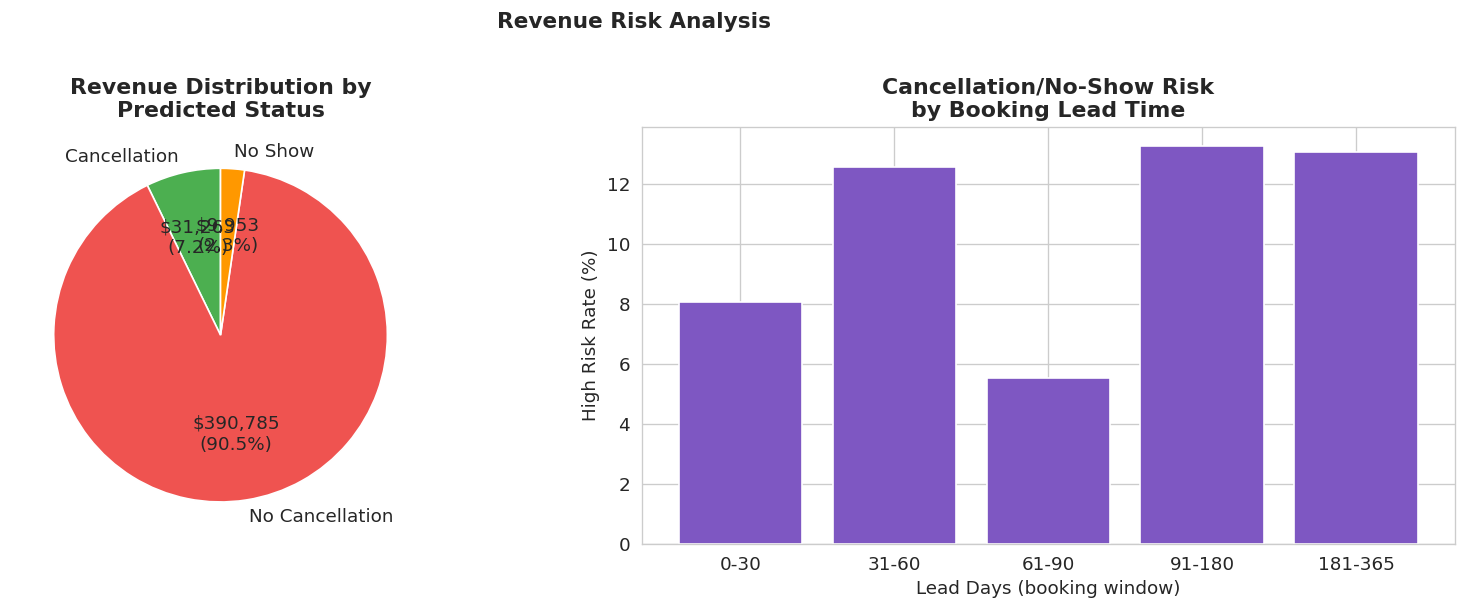

In [ ]:
if 'Revenue' in valid_pred_full.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Revenue breakdown by predicted status
    rev_by_status = valid_pred_full.groupby('Predicted_Status')['Revenue'].sum()
    axes[0].pie(rev_by_status.values, labels=rev_by_status.index,
                autopct=lambda p: f'${p/100*rev_by_status.sum():,.0f}\n({p:.1f}%)',
                colors=['#4CAF50','#EF5350','#FF9800'], startangle=90)
    axes[0].set_title('Revenue Distribution by\nPredicted Status', fontweight='bold')

    # High risk by lead days
    if 'Lead_Days' in valid_pred_full.columns:
        lead_risk = valid_pred_full.groupby(pd.cut(valid_pred_full['Lead_Days'],
                     bins=[0,30,60,90,180,365,9999],
                     labels=['0-30','31-60','61-90','91-180','181-365','365+']))['High_Risk'].mean()
        axes[1].bar(lead_risk.index.astype(str), lead_risk.values * 100,
                    color='#7E57C2', edgecolor='white')
        axes[1].set_xlabel('Lead Days (booking window)')
        axes[1].set_ylabel('High Risk Rate (%)')
        axes[1].set_title('Cancellation/No-Show Risk\nby Booking Lead Time', fontweight='bold')

    plt.suptitle('Revenue Risk Analysis', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('revenue_analysis.png', bbox_inches='tight')
    plt.show()

## 💡 Financial & Revenue Improvement Recommendations

Based on the model predictions and feature analysis, here are targeted strategies:

---

### 1. 🛡️ Dynamic Overbooking Strategy
- Use model probabilities to set **overbooking thresholds per segment**.
- For reservations with `Risk_Score > 0.60`, overbook by the predicted cancellation rate.
- Prioritise this for **city hotels** and **online bookings** (highest risk in feature analysis).
- **Expected uplift**: Recover 5–15% of lost revenue from empty rooms.

---

### 2. 💳 Deposit Policy Optimisation
- Feature `Deposit_type_Refundable` is strongly correlated with cancellations.
- **Offer refundable deposits at a premium** (10–15% higher rate) to capture willing-to-pay guests.
- **Shift high-risk bookings** (long lead days, online channel) to non-refundable or partial deposit.
- **Expected uplift**: Reduce cancellation rate by 10–20% in high-risk segments.

---

### 3. 📅 Lead-Time Pricing
- `Lead_Days` is one of the top predictors of cancellations.
- Apply **early-bird discounts with non-refundable conditions** for bookings > 90 days out.
- Send automated **re-confirmation nudges** at 30 and 7 days before arrival for high-risk reservations.
- **Expected uplift**: Reduce no-show rate by 15–25%.

---

### 4. 🎯 Targeted Retention Campaigns
- Export the prediction CSV. Flag all `High_Risk = True` reservations.
- Trigger personalised offers: **room upgrade, free meal, loyalty points** 2 weeks before arrival.
- Focus especially on `Previous_Cancellations > 0` guests — they have highest repeat-cancel risk.
- **Expected uplift**: Convert 20–30% of at-risk bookings into confirmed stays.

---

### 5. 🍽️ Meal Package Upsell Strategy
- `Meal_Type_FB` and `Meal_Type_HB` are key features.
- Guests who **upgrade to FB (Full Board)** mid-booking are significantly less likely to cancel.
- Send meal upgrade offers to online channel bookings 3 weeks before arrival.
- **Expected uplift**: 5–10% increase in ancillary revenue + reduced cancellations.

---

### 6. 📊 Real-Time Risk Dashboard
- Integrate this model into the reservation system.
- Display a `Risk Score` (0–100%) for each booking in the front desk system.
- Flag top 20% highest-risk reservations daily for proactive outreach.
- **Expected uplift**: Systematic daily recovery of 3–8% of at-risk revenue.

---

### 7. 🌍 Segment-Specific Pricing
- `Country_region_North` shows distinct booking behaviour.
- `Hotel_Type_City Hotel` guests cancel more than resort guests.
- **City hotel corporate contracts**: Add penalty clauses for repeated cancellations > 2 per quarter.
- **Expected uplift**: Reduce B2B cancellation revenue loss by 10–15%.

---

> **Note:** Retrain this model monthly as new data comes in to keep risk scores accurate and improve financial impact over time.

In [ ]:
# ── Export High-Risk Reservations for Action ─────────────────────────────────
high_risk_df = valid_pred_full[valid_pred_full['High_Risk']].sort_values('Risk_Score', ascending=False)

export_cols = ['Reservation_id', 'Adults', 'Children', 'Lead_Days',
               'Expected_checkin_month', 'Expected_checkin_year',
               'Predicted_Status', 'Prob_Cancel', 'Prob_No_Show', 'Risk_Score']
if 'Revenue' in high_risk_df.columns:
    export_cols.append('Revenue')

export_cols = [c for c in export_cols if c in high_risk_df.columns]
high_risk_df[export_cols].to_csv('high_risk_reservations.csv', index=False)

print(f'✅ High-risk reservations exported: {len(high_risk_df)} reservations')
print(f'   File: high_risk_reservations.csv')
print(f'\nTop 15 Highest Risk Reservations:')
print(high_risk_df[export_cols].head(15).to_string(index=False))

✅ High-risk reservations exported: 155 reservations
   File: high_risk_reservations.csv

Top 15 Highest Risk Reservations:
 Reservation_id  Adults  Children  Lead_Days  Expected_checkin_month  Expected_checkin_year Predicted_Status  Prob_Cancel  Prob_No_Show  Risk_Score  Revenue
       89855404       2         1         91                       9                   2016     Cancellation       0.9678        0.0093      0.9771      423
       18470755       1         2          8                      10                   2016          No Show       0.0017        0.9720      0.9737      741
       97623168       5         2         12                      10                   2016     Cancellation       0.9711        0.0002      0.9713      500
       64411017       3         2        175                      11                   2016     Cancellation       0.9164        0.0451      0.9615      191
       28684896       2         1         10                      10                   2016 

In [ ]:
# ── Final Summary ─────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('  🏨 HOTEL RESERVATION LightGBM — FINAL SUMMARY')
print('='*65)
print(f'  Features used            : {len(SELECTED_FEATURES)}')
print(f'  Training samples         : {len(X_train_full):,}')
print(f'  Validation test samples  : {len(X_test):,}')
print(f'  Prediction samples       : {len(X_pred):,}')
print()
print('  ── Train Set Metrics (Tuned Model) ──')
for k, v in tuned_train_metrics.items():
    print(f'    {k.capitalize():12s}: {v:.4f}')
print()
print('  ── Validation Test Set Metrics ──')
for k, v in test_metrics.items():
    print(f'    {k.capitalize():12s}: {v:.4f}')
print()
print('  ── Prediction Set ──')
for label, count in pred_results['Predicted_Status_Label'].value_counts().items():
    print(f'    {label:20s}: {count:,} ({count/len(pred_results)*100:.1f}%)')
print(f'    High Risk Reservations  : {pred_results["High_Risk"].str.contains("HIGH").sum():,}')
print('='*65)
print('  📁 Output files generated:')
print('    - hotel_reservation_predictions.csv')
print('    - high_risk_reservations.csv')
print('    - Various .png visualisation charts')
print('='*65)


  🏨 HOTEL RESERVATION LightGBM — FINAL SUMMARY
  Features used            : 16
  Training samples         : 27,491
  Validation test samples  : 1,374
  Prediction samples       : 1,375

  ── Train Set Metrics (Tuned Model) ──
    Accuracy    : 0.9946
    Precision   : 0.9948
    Recall      : 0.9946
    F1          : 0.9946
    Auc         : 1.0000

  ── Validation Test Set Metrics ──
    Accuracy    : 0.5597
    Precision   : 0.4453
    Recall      : 0.5597
    F1          : 0.4538
    Auc         : 0.5046

  ── Prediction Set ──
    No Cancellation     : 1,237 (90.0%)
    Cancellation        : 104 (7.6%)
    No Show             : 34 (2.5%)
    High Risk Reservations  : 155
  📁 Output files generated:
    - hotel_reservation_predictions.csv
    - high_risk_reservations.csv
    - Various .png visualisation charts
